# Fitting a Logistic Regression : South African heart disease

### Reproducing Hastie, Tibshirani and Friedman (2009), section 4.4.1

In [ ]:
import pandas as pd
import io
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

Let us read and examine the data

   row.names  sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  \
0          1  160    12.00  5.73      23.11  Present     49    25.30    97.20   
1          2  144     0.01  4.41      28.61   Absent     55    28.87     2.06   
2          3  118     0.08  3.48      32.28  Present     52    29.14     3.81   
3          4  170     7.50  6.41      38.03  Present     51    31.99    24.26   
4          5  134    13.60  3.50      27.78  Present     60    25.99    57.34   

   age  chd  
0   52    1  
1   63    1  
2   46    0  
3   58    1  
4   49    1  


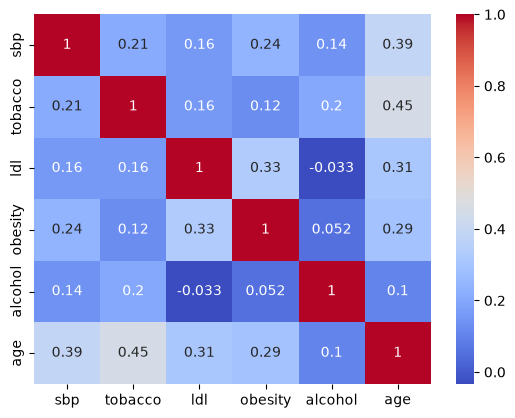

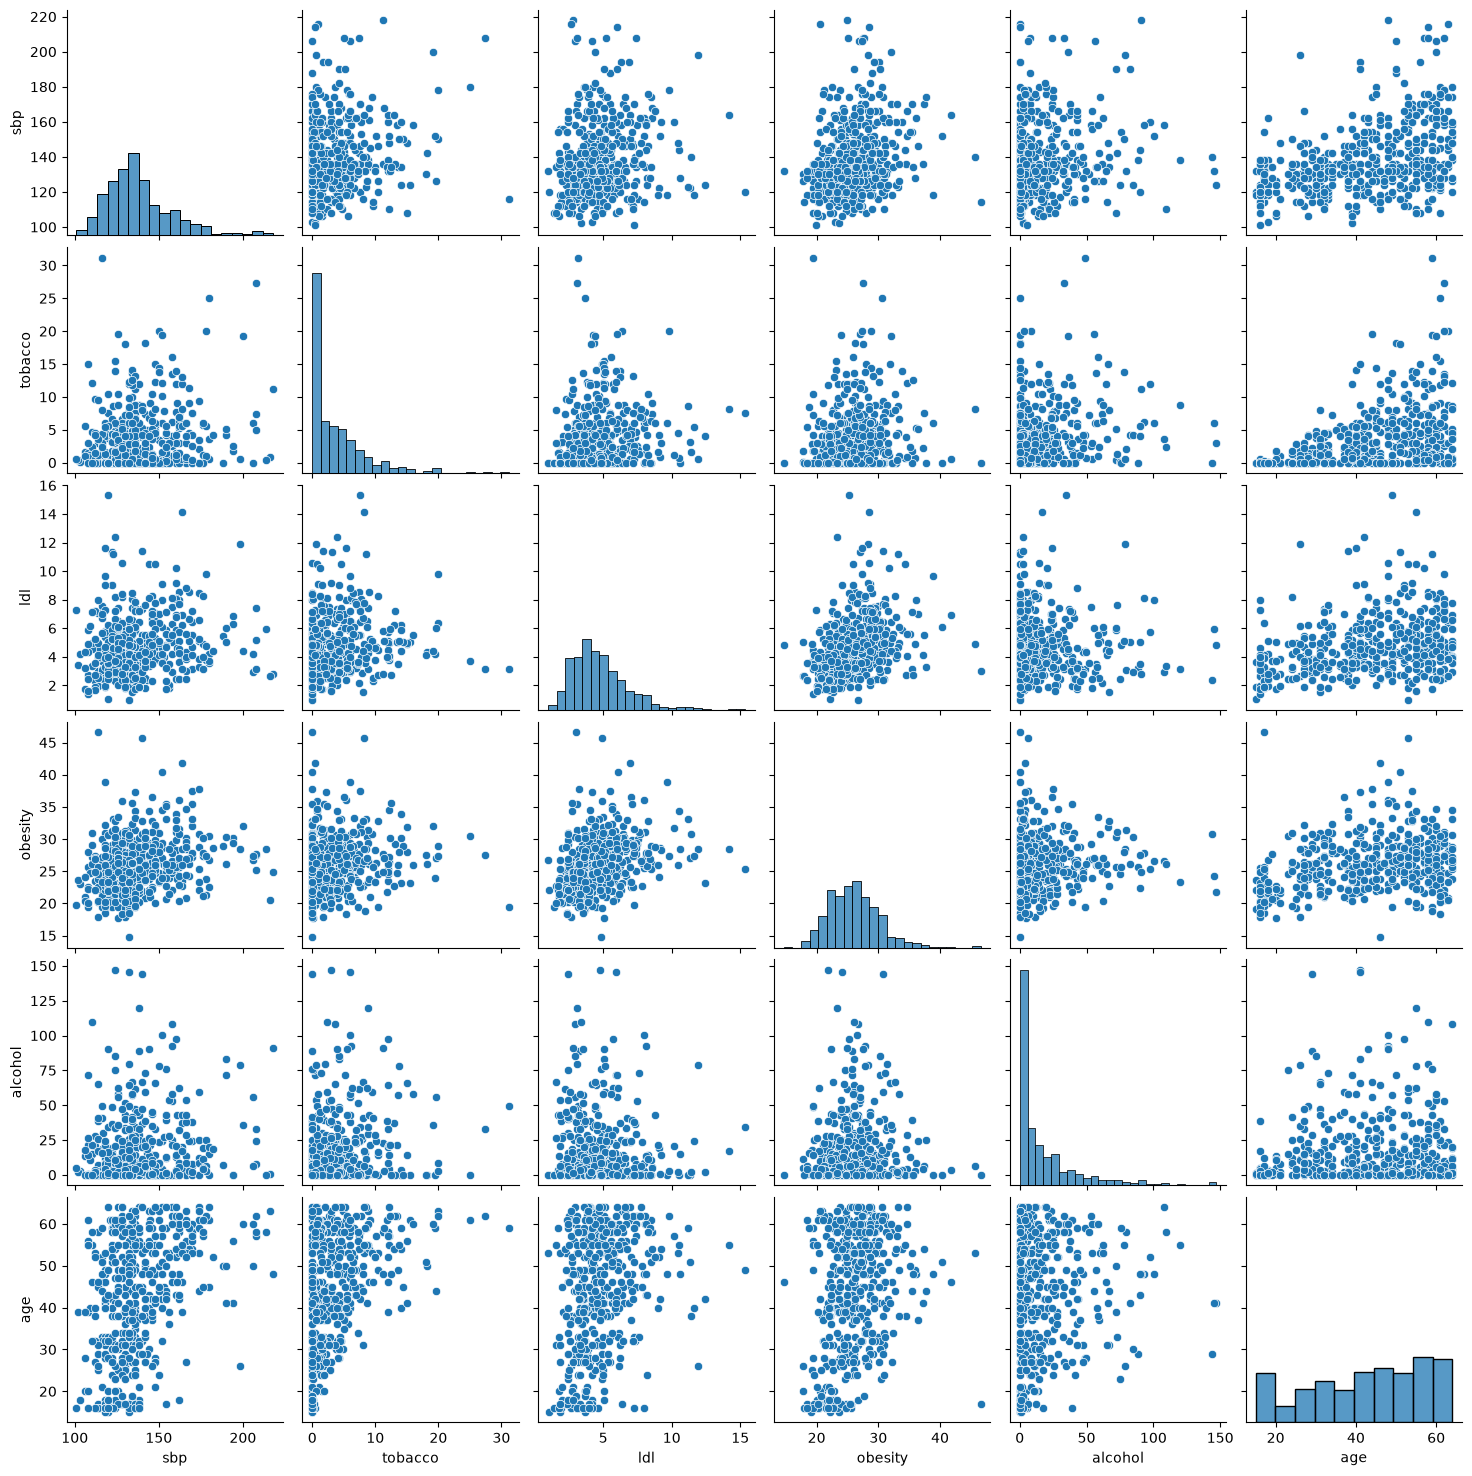

In [52]:
raw_data = """row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
1,160,12.00, 5.73,23.11,Present,49,25.30, 97.20,52,1
2,144, 0.01, 4.41,28.61,Absent,55,28.87,  2.06,63,1
3,118, 0.08, 3.48,32.28,Present,52,29.14,  3.81,46,0
4,170, 7.50, 6.41,38.03,Present,51,31.99, 24.26,58,1
5,134,13.60, 3.50,27.78,Present,60,25.99, 57.34,49,1
6,132, 6.20, 6.47,36.21,Present,62,30.77, 14.14,45,0
7,142, 4.05, 3.38,16.20,Absent,59,20.81,  2.62,38,0
8,114, 4.08, 4.59,14.60,Present,62,23.11,  6.72,58,1
9,114, 0.00, 3.83,19.40,Present,49,24.86,  2.49,29,0
10,132, 0.00, 5.80,30.96,Present,69,30.11,  0.00,53,1
11,206, 6.00, 2.95,32.27,Absent,72,26.81, 56.06,60,1
12,134,14.10, 4.44,22.39,Present,65,23.09,  0.00,40,1
13,118, 0.00, 1.88,10.05,Absent,59,21.57,  0.00,17,0
14,132, 0.00, 1.87,17.21,Absent,49,23.63,  0.97,15,0
15,112, 9.65, 2.29,17.20,Present,54,23.53,  0.68,53,0
16,117, 1.53, 2.44,28.95,Present,35,25.89, 30.03,46,0
17,120, 7.50,15.33,22.00,Absent,60,25.31, 34.49,49,0
18,146,10.50, 8.29,35.36,Present,78,32.73, 13.89,53,1
19,158, 2.60, 7.46,34.07,Present,61,29.30, 53.28,62,1
20,124,14.00, 6.23,35.96,Present,45,30.09,  0.00,59,1
21,106, 1.61, 1.74,12.32,Absent,74,20.92, 13.37,20,1
22,132, 7.90, 2.85,26.50,Present,51,26.16, 25.71,44,0
23,150, 0.30, 6.38,33.99,Present,62,24.64,  0.00,50,0
24,138, 0.60, 3.81,28.66,Absent,54,28.70,  1.46,58,0
25,142,18.20, 4.34,24.38,Absent,61,26.19,  0.00,50,0
26,124, 4.00,12.42,31.29,Present,54,23.23,  2.06,42,1
27,118, 6.00, 9.65,33.91,Absent,60,38.80,  0.00,48,0
28,145, 9.10, 5.24,27.55,Absent,59,20.96, 21.60,61,1
29,144, 4.09, 5.55,31.40,Present,60,29.43,  5.55,56,0
30,146, 0.00, 6.62,25.69,Absent,60,28.07,  8.23,63,1
31,136, 2.52, 3.95,25.63,Absent,51,21.86,  0.00,45,1
32,158, 1.02, 6.33,23.88,Absent,66,22.13, 24.99,46,1
33,122, 6.60, 5.58,35.95,Present,53,28.07, 12.55,59,1
34,126, 8.75, 6.53,34.02,Absent,49,30.25,  0.00,41,1
35,148, 5.50, 7.10,25.31,Absent,56,29.84,  3.60,48,0
36,122, 4.26, 4.44,13.04,Absent,57,19.49, 48.99,28,1
37,140, 3.90, 7.32,25.05,Absent,47,27.36, 36.77,32,0
38,110, 4.64, 4.55,30.46,Absent,48,30.90, 15.22,46,0
39,130, 0.00, 2.82,19.63,Present,70,24.86,  0.00,29,0
40,136,11.20, 5.81,31.85,Present,75,27.68, 22.94,58,1
41,118, 0.28, 5.80,33.70,Present,60,30.98,  0.00,41,1
42,144, 0.04, 3.38,23.61,Absent,30,23.75,  4.66,30,0
43,120, 0.00, 1.07,16.02,Absent,47,22.15,  0.00,15,0
44,130, 2.61, 2.72,22.99,Present,51,26.29, 13.37,51,1
45,114, 0.00, 2.99, 9.74,Absent,54,46.58,  0.00,17,0
46,128, 4.65, 3.31,22.74,Absent,62,22.95,  0.51,48,0
47,162, 7.40, 8.55,24.65,Present,64,25.71,  5.86,58,1
48,116, 1.91, 7.56,26.45,Present,52,30.01,  3.60,33,1
49,114, 0.00, 1.94,11.02,Absent,54,20.17, 38.98,16,0
50,126, 3.80, 3.88,31.79,Absent,57,30.53,  0.00,30,0
51,122, 0.00, 5.75,30.90,Present,46,29.01,  4.11,42,0
52,134, 2.50, 3.66,30.90,Absent,52,27.19, 23.66,49,0
53,152, 0.90, 9.12,30.23,Absent,56,28.64,  0.37,42,1
54,134, 8.08, 1.55,17.50,Present,56,22.65, 66.65,31,1
55,156, 3.00, 1.82,27.55,Absent,60,23.91, 54.00,53,0
56,152, 5.99, 7.99,32.48,Absent,45,26.57,100.32,48,0
57,118, 0.00, 2.99,16.17,Absent,49,23.83,  3.22,28,0
58,126, 5.10, 2.96,26.50,Absent,55,25.52, 12.34,38,1
59,103, 0.03, 4.21,18.96,Absent,48,22.94,  2.62,18,0
60,121, 0.80, 5.29,18.95,Present,47,22.51,  0.00,61,0
61,142, 0.28, 1.80,21.03,Absent,57,23.65,  2.93,33,0
62,138, 1.15, 5.09,27.87,Present,61,25.65,  2.34,44,0
63,152,10.10, 4.71,24.65,Present,65,26.21, 24.53,57,0
64,140, 0.45, 4.30,24.33,Absent,41,27.23, 10.08,38,0
65,130, 0.00, 1.82,10.45,Absent,57,22.07,  2.06,17,0
66,136, 7.36, 2.19,28.11,Present,61,25.00, 61.71,54,0
67,124, 4.82, 3.24,21.10,Present,48,28.49,  8.42,30,0
68,112, 0.41, 1.88,10.29,Absent,39,22.08, 20.98,27,0
69,118, 4.46, 7.27,29.13,Present,48,29.01, 11.11,33,0
70,122, 0.00, 3.37,16.10,Absent,67,21.06,  0.00,32,1
71,118, 0.00, 3.67,12.13,Absent,51,19.15,  0.60,15,0
72,130, 1.72, 2.66,10.38,Absent,68,17.81, 11.10,26,0
73,130, 5.60, 3.37,24.80,Absent,58,25.76, 43.20,36,0
74,126, 0.09, 5.03,13.27,Present,50,17.75,  4.63,20,0
75,128, 0.40, 6.17,26.35,Absent,64,27.86, 11.11,34,0
76,136, 0.00, 4.12,17.42,Absent,52,21.66, 12.86,40,0
77,134, 0.00, 5.90,30.84,Absent,49,29.16,  0.00,55,0
78,140, 0.60, 5.56,33.39,Present,58,27.19,  0.00,55,1
79,168, 4.50, 6.68,28.47,Absent,43,24.25, 24.38,56,1
80,108, 0.40, 5.91,22.92,Present,57,25.72, 72.00,39,0
81,114, 3.00, 7.04,22.64,Present,55,22.59,  0.00,45,1
82,140, 8.14, 4.93,42.49,Absent,53,45.72,  6.43,53,1
83,148, 4.80, 6.09,36.55,Present,63,25.44,  0.88,55,1
84,148,12.20, 3.79,34.15,Absent,57,26.38, 14.40,57,1
85,128, 0.00, 2.43,13.15,Present,63,20.75,  0.00,17,0
86,130, 0.56, 3.30,30.86,Absent,49,27.52, 33.33,45,0
87,126,10.50, 4.49,17.33,Absent,67,19.37,  0.00,49,1
88,140, 0.00, 5.08,27.33,Present,41,27.83,  1.25,38,0
89,126, 0.90, 5.64,17.78,Present,55,21.94,  0.00,41,0
90,122, 0.72, 4.04,32.38,Absent,34,28.34,  0.00,55,0
91,116, 1.03, 2.83,10.85,Absent,45,21.59,  1.75,21,0
92,120, 3.70, 4.02,39.66,Absent,61,30.57,  0.00,64,1
93,143, 0.46, 2.40,22.87,Absent,62,29.17, 15.43,29,0
94,118, 4.00, 3.95,18.96,Absent,54,25.15,  8.33,49,1
95,194, 1.70, 6.32,33.67,Absent,47,30.16,  0.19,56,0
96,134, 3.00, 4.37,23.07,Absent,56,20.54,  9.65,62,0
97,138, 2.16, 4.90,24.83,Present,39,26.06, 28.29,29,0
98,136, 0.00, 5.00,27.58,Present,49,27.59,  1.47,39,0
99,122, 3.20,11.32,35.36,Present,55,27.07,  0.00,51,1
100,164,12.00, 3.91,19.59,Absent,51,23.44, 19.75,39,0
101,136, 8.00, 7.85,23.81,Present,51,22.69,  2.78,50,0
102,166, 0.07, 4.03,29.29,Absent,53,28.37,  0.00,27,0
103,118, 0.00, 4.34,30.12,Present,52,32.18,  3.91,46,0
104,128, 0.42, 4.60,26.68,Absent,41,30.97, 10.33,31,0
105,118, 1.50, 5.38,25.84,Absent,64,28.63,  3.89,29,0
106,158, 3.60, 2.97,30.11,Absent,63,26.64,108.00,64,0
107,108, 1.50, 4.33,24.99,Absent,66,22.29, 21.60,61,1
108,170, 7.60, 5.50,37.83,Present,42,37.41,  6.17,54,1
109,118, 1.00, 5.76,22.10,Absent,62,23.48,  7.71,42,0
110,124, 0.00, 3.04,17.33,Absent,49,22.04,  0.00,18,0
111,114, 0.00, 8.01,21.64,Absent,66,25.51,  2.49,16,0
112,168, 9.00, 8.53,24.48,Present,69,26.18,  4.63,54,1
113,134, 2.00, 3.66,14.69,Absent,52,21.03,  2.06,37,0
114,174, 0.00, 8.46,35.10,Present,35,25.27,  0.00,61,1
115,116,31.20, 3.17,14.99,Absent,47,19.40, 49.06,59,1
116,128, 0.00,10.58,31.81,Present,46,28.41, 14.66,48,0
117,140, 4.50, 4.59,18.01,Absent,63,21.91, 22.09,32,1
118,154, 0.70, 5.91,25.00,Absent,13,20.60,  0.00,42,0
119,150, 3.50, 6.99,25.39,Present,50,23.35, 23.48,61,1
120,130, 0.00, 3.92,25.55,Absent,68,28.02,  0.68,27,0
121,128, 2.00, 6.13,21.31,Absent,66,22.86, 11.83,60,0
122,120, 1.40, 6.25,20.47,Absent,60,25.85,  8.51,28,0
123,120, 0.00, 5.01,26.13,Absent,64,26.21, 12.24,33,0
124,138, 4.50, 2.85,30.11,Absent,55,24.78, 24.89,56,1
125,153, 7.80, 3.96,25.73,Absent,54,25.91, 27.03,45,0
126,123, 8.60,11.17,35.28,Present,70,33.14,  0.00,59,1
127,148, 4.04, 3.99,20.69,Absent,60,27.78,  1.75,28,0
128,136, 3.96, 2.76,30.28,Present,50,34.42, 18.51,38,0
129,134, 8.80, 7.41,26.84,Absent,35,29.44, 29.52,60,1
130,152,12.18, 4.04,37.83,Present,63,34.57,  4.17,64,0
131,158,13.50, 5.04,30.79,Absent,54,24.79, 21.50,62,0
132,132, 2.00, 3.08,35.39,Absent,45,31.44, 79.82,58,1
133,134, 1.50, 3.73,21.53,Absent,41,24.70, 11.11,30,1
134,142, 7.44, 5.52,33.97,Absent,47,29.29, 24.27,54,0
135,134, 6.00, 3.30,28.45,Absent,65,26.09, 58.11,40,0
136,122, 4.18, 9.05,29.27,Present,44,24.05, 19.34,52,1
137,116, 2.70, 3.69,13.52,Absent,55,21.13, 18.51,32,0
138,128, 0.50, 3.70,12.81,Present,66,21.25, 22.73,28,0
139,120, 0.00, 3.68,12.24,Absent,51,20.52,  0.51,20,0
140,124, 0.00, 3.95,36.35,Present,59,32.83,  9.59,54,0
141,160,14.00, 5.90,37.12,Absent,58,33.87,  3.52,54,1
142,130, 2.78, 4.89, 9.39,Present,63,19.30, 17.47,25,1
143,128, 2.80, 5.53,14.29,Absent,64,24.97,  0.51,38,0
144,130, 4.50, 5.86,37.43,Absent,61,31.21, 32.30,58,0
145,109, 1.20, 6.14,29.26,Absent,47,24.72, 10.46,40,0
146,144, 0.00, 3.84,18.72,Absent,56,22.10,  4.80,40,0
147,118, 1.05, 3.16,12.98,Present,46,22.09, 16.35,31,0
148,136, 3.46, 6.38,32.25,Present,43,28.73,  3.13,43,1
149,136, 1.50, 6.06,26.54,Absent,54,29.38, 14.50,33,1
150,124,15.50, 5.05,24.06,Absent,46,23.22,  0.00,61,1
151,148, 6.00, 6.49,26.47,Absent,48,24.70,  0.00,55,0
152,128, 6.60, 3.58,20.71,Absent,55,24.15,  0.00,52,0
153,122, 0.28, 4.19,19.97,Absent,61,25.63,  0.00,24,0
154,108, 0.00, 2.74,11.17,Absent,53,22.61,  0.95,20,0
155,124, 3.04, 4.80,19.52,Present,60,21.78,147.19,41,1
156,138, 8.80, 3.12,22.41,Present,63,23.33,120.03,55,1
157,127, 0.00, 2.81,15.70,Absent,42,22.03,  1.03,17,0
158,174, 9.45, 5.13,35.54,Absent,55,30.71, 59.79,53,0
159,122, 0.00, 3.05,23.51,Absent,46,25.81,  0.00,38,0
160,144, 6.75, 5.45,29.81,Absent,53,25.62, 26.23,43,1
161,126, 1.80, 6.22,19.71,Absent,65,24.81,  0.69,31,0
162,208,27.40, 3.12,26.63,Absent,66,27.45, 33.07,62,1
163,138, 0.00, 2.68,17.04,Absent,42,22.16,  0.00,16,0
164,148, 0.00, 3.84,17.26,Absent,70,20.00,  0.00,21,0
165,122, 0.00, 3.08,16.30,Absent,43,22.13,  0.00,16,0
166,132, 7.00, 3.20,23.26,Absent,77,23.64, 23.14,49,0
167,110,12.16, 4.99,28.56,Absent,44,27.14, 21.60,55,1
168,160, 1.52, 8.12,29.30,Present,54,25.87, 12.86,43,1
169,126, 0.54, 4.39,21.13,Present,45,25.99,  0.00,25,0
170,162, 5.30, 7.95,33.58,Present,58,36.06,  8.23,48,0
171,194, 2.55, 6.89,33.88,Present,69,29.33,  0.00,41,0
172,118, 0.75, 2.58,20.25,Absent,59,24.46,  0.00,32,0
173,124, 0.00, 4.79,34.71,Absent,49,26.09,  9.26,47,0
174,160, 0.00, 2.42,34.46,Absent,48,29.83,  1.03,61,0
175,128, 0.00, 2.51,29.35,Present,53,22.05,  1.37,62,0
176,122, 4.00, 5.24,27.89,Present,45,26.52,  0.00,61,1
177,132, 2.00, 2.70,21.57,Present,50,27.95,  9.26,37,0
178,120, 0.00, 2.42,16.66,Absent,46,20.16,  0.00,17,0
179,128, 0.04, 8.22,28.17,Absent,65,26.24, 11.73,24,0
180,108,15.00, 4.91,34.65,Absent,41,27.96, 14.40,56,0
181,166, 0.00, 4.31,34.27,Absent,45,30.14, 13.27,56,0
182,152, 0.00, 6.06,41.05,Present,51,40.34,  0.00,51,0
183,170, 4.20, 4.67,35.45,Present,50,27.14,  7.92,60,1
184,156, 4.00, 2.05,19.48,Present,50,21.48, 27.77,39,1
185,116, 8.00, 6.73,28.81,Present,41,26.74, 40.94,48,1
186,122, 4.40, 3.18,11.59,Present,59,21.94,  0.00,33,1
187,150,20.00, 6.40,35.04,Absent,53,28.88,  8.33,63,0
188,129, 2.15, 5.17,27.57,Absent,52,25.42,  2.06,39,0
189,134, 4.80, 6.58,29.89,Present,55,24.73, 23.66,63,0
190,126, 0.00, 5.98,29.06,Present,56,25.39, 11.52,64,1
191,142, 0.00, 3.72,25.68,Absent,48,24.37,  5.25,40,1
192,128, 0.70, 4.90,37.42,Present,72,35.94,  3.09,49,1
193,102, 0.40, 3.41,17.22,Present,56,23.59,  2.06,39,1
194,130, 0.00, 4.89,25.98,Absent,72,30.42, 14.71,23,0
195,138, 0.05, 2.79,10.35,Absent,46,21.62,  0.00,18,0
196,138, 0.00, 1.96,11.82,Present,54,22.01,  8.13,21,0
197,128, 0.00, 3.09,20.57,Absent,54,25.63,  0.51,17,0
198,162, 2.92, 3.63,31.33,Absent,62,31.59, 18.51,42,0
199,160, 3.00, 9.19,26.47,Present,39,28.25, 14.40,54,1
200,148, 0.00, 4.66,24.39,Absent,50,25.26,  4.03,27,0
201,124, 0.16, 2.44,16.67,Absent,65,24.58, 74.91,23,0
202,136, 3.15, 4.37,20.22,Present,59,25.12, 47.16,31,1
203,134, 2.75, 5.51,26.17,Absent,57,29.87,  8.33,33,0
204,128, 0.73, 3.97,23.52,Absent,54,23.81, 19.20,64,0
205,122, 3.20, 3.59,22.49,Present,45,24.96, 36.17,58,0
206,152, 3.00, 4.64,31.29,Absent,41,29.34,  4.53,40,0
207,162, 0.00, 5.09,24.60,Present,64,26.71,  3.81,18,0
208,124, 4.00, 6.65,30.84,Present,54,28.40, 33.51,60,0
209,136, 5.80, 5.90,27.55,Absent,65,25.71, 14.40,59,0
210,136, 8.80, 4.26,32.03,Present,52,31.44, 34.35,60,0
211,134, 0.05, 8.03,27.95,Absent,48,26.88,  0.00,60,0
212,122, 1.00, 5.88,34.81,Present,69,31.27, 15.94,40,1
213,116, 3.00, 3.05,30.31,Absent,41,23.63,  0.86,44,0
214,132, 0.00, 0.98,21.39,Absent,62,26.75,  0.00,53,0
215,134, 0.00, 2.40,21.11,Absent,57,22.45,  1.37,18,0
216,160, 7.77, 8.07,34.80,Absent,64,31.15,  0.00,62,1
217,180, 0.52, 4.23,16.38,Absent,55,22.56, 14.77,45,1
218,124, 0.81, 6.16,11.61,Absent,35,21.47, 10.49,26,0
219,114, 0.00, 4.97, 9.69,Absent,26,22.60,  0.00,25,0
220,208, 7.40, 7.41,32.03,Absent,50,27.62,  7.85,57,0
221,138, 0.00, 3.14,12.00,Absent,54,20.28,  0.00,16,0
222,164, 0.50, 6.95,39.64,Present,47,41.76,  3.81,46,1
223,144, 2.40, 8.13,35.61,Absent,46,27.38, 13.37,60,0
224,136, 7.50, 7.39,28.04,Present,50,25.01,  0.00,45,1
225,132, 7.28, 3.52,12.33,Absent,60,19.48,  2.06,56,0
226,143, 5.04, 4.86,23.59,Absent,58,24.69, 18.72,42,0
227,112, 4.46, 7.18,26.25,Present,69,27.29,  0.00,32,1
228,134,10.00, 3.79,34.72,Absent,42,28.33, 28.80,52,1
229,138, 2.00, 5.11,31.40,Present,49,27.25,  2.06,64,1
230,188, 0.00, 5.47,32.44,Present,71,28.99,  7.41,50,1
231,110, 2.35, 3.36,26.72,Present,54,26.08,109.80,58,1
232,136,13.20, 7.18,35.95,Absent,48,29.19,  0.00,62,0
233,130, 1.75, 5.46,34.34,Absent,53,29.42,  0.00,58,1
234,122, 0.00, 3.76,24.59,Absent,56,24.36,  0.00,30,0
235,138, 0.00, 3.24,27.68,Absent,60,25.70, 88.66,29,0
236,130,18.00, 4.13,27.43,Absent,54,27.44,  0.00,51,1
237,126, 5.50, 3.78,34.15,Absent,55,28.85,  3.18,61,0
238,176, 5.76, 4.89,26.10,Present,46,27.30, 19.44,57,0
239,122, 0.00, 5.49,19.56,Absent,57,23.12, 14.02,27,0
240,124, 0.00, 3.23, 9.64,Absent,59,22.70,  0.00,16,0
241,140, 5.20, 3.58,29.26,Absent,70,27.29, 20.17,45,1
242,128, 6.00, 4.37,22.98,Present,50,26.01,  0.00,47,0
243,190, 4.18, 5.05,24.83,Absent,45,26.09, 82.85,41,0
244,144, 0.76,10.53,35.66,Absent,63,34.35,  0.00,55,1
245,126, 4.60, 7.40,31.99,Present,57,28.67,  0.37,60,1
246,128, 0.00, 2.63,23.88,Absent,45,21.59,  6.54,57,0
247,136, 0.40, 3.91,21.10,Present,63,22.30,  0.00,56,1
248,158, 4.00, 4.18,28.61,Present,42,25.11,  0.00,60,0
249,160, 0.60, 6.94,30.53,Absent,36,25.68,  1.42,64,0
250,124, 6.00, 5.21,33.02,Present,64,29.37,  7.61,58,1
251,158, 6.17, 8.12,30.75,Absent,46,27.84, 92.62,48,0
252,128, 0.00, 6.34,11.87,Absent,57,23.14,  0.00,17,0
253,166, 3.00, 3.82,26.75,Absent,45,20.86,  0.00,63,1
254,146, 7.50, 7.21,25.93,Present,55,22.51,  0.51,42,0
255,161, 9.00, 4.65,15.16,Present,58,23.76, 43.20,46,0
256,164,13.02, 6.26,29.38,Present,47,22.75, 37.03,54,1
257,146, 5.08, 7.03,27.41,Present,63,36.46, 24.48,37,1
258,142, 4.48, 3.57,19.75,Present,51,23.54,  3.29,49,0
259,138,12.00, 5.13,28.34,Absent,59,24.49, 32.81,58,1
260,154, 1.80, 7.13,34.04,Present,52,35.51, 39.36,44,0
261,118, 0.00, 2.39,12.13,Absent,49,18.46,  0.26,17,1
263,124, 0.61, 2.69,17.15,Present,61,22.76, 11.55,20,0
264,124, 1.04, 2.84,16.42,Present,46,20.17,  0.00,61,0
265,136, 5.00, 4.19,23.99,Present,68,27.80, 25.86,35,0
266,132, 9.90, 4.63,27.86,Present,46,23.39,  0.51,52,1
267,118, 0.12, 1.96,20.31,Absent,37,20.01,  2.42,18,0
268,118, 0.12, 4.16, 9.37,Absent,57,19.61,  0.00,17,0
269,134,12.00, 4.96,29.79,Absent,53,24.86,  8.23,57,0
270,114, 0.10, 3.95,15.89,Present,57,20.31, 17.14,16,0
271,136, 6.80, 7.84,30.74,Present,58,26.20, 23.66,45,1
272,130, 0.00, 4.16,39.43,Present,46,30.01,  0.00,55,1
273,136, 2.20, 4.16,38.02,Absent,65,37.24,  4.11,41,1
274,136, 1.36, 3.16,14.97,Present,56,24.98,  7.30,24,0
275,154, 4.20, 5.59,25.02,Absent,58,25.02,  1.54,43,0
276,108, 0.80, 2.47,17.53,Absent,47,22.18,  0.00,55,1
277,136, 8.80, 4.69,36.07,Present,38,26.56,  2.78,63,1
278,174, 2.02, 6.57,31.90,Present,50,28.75, 11.83,64,1
279,124, 4.25, 8.22,30.77,Absent,56,25.80,  0.00,43,0
280,114, 0.00, 2.63, 9.69,Absent,45,17.89,  0.00,16,0
281,118, 0.12, 3.26,12.26,Absent,55,22.65,  0.00,16,0
282,106, 1.08, 4.37,26.08,Absent,67,24.07, 17.74,28,1
283,146, 3.60, 3.51,22.67,Absent,51,22.29, 43.71,42,0
284,206, 0.00, 4.17,33.23,Absent,69,27.36,  6.17,50,1
285,134, 3.00, 3.17,17.91,Absent,35,26.37, 15.12,27,0
286,148,15.00, 4.98,36.94,Present,72,31.83, 66.27,41,1
287,126, 0.21, 3.95,15.11,Absent,61,22.17,  2.42,17,0
288,134, 0.00, 3.69,13.92,Absent,43,27.66,  0.00,19,0
289,134, 0.02, 2.80,18.84,Absent,45,24.82,  0.00,17,0
290,123, 0.05, 4.61,13.69,Absent,51,23.23,  2.78,16,0
291,112, 0.60, 5.28,25.71,Absent,55,27.02, 27.77,38,1
292,112, 0.00, 1.71,15.96,Absent,42,22.03,  3.50,16,0
293,101, 0.48, 7.26,13.00,Absent,50,19.82,  5.19,16,0
294,150, 0.18, 4.14,14.40,Absent,53,23.43,  7.71,44,0
295,170, 2.60, 7.22,28.69,Present,71,27.87, 37.65,56,1
296,134, 0.00, 5.63,29.12,Absent,68,32.33,  2.02,34,0
297,142, 0.00, 4.19,18.04,Absent,56,23.65, 20.78,42,1
298,132, 0.10, 3.28,10.73,Absent,73,20.42,  0.00,17,0
299,136, 0.00, 2.28,18.14,Absent,55,22.59,  0.00,17,0
300,132,12.00, 4.51,21.93,Absent,61,26.07, 64.80,46,1
301,166, 4.10, 4.00,34.30,Present,32,29.51,  8.23,53,0
302,138, 0.00, 3.96,24.70,Present,53,23.80,  0.00,45,0
303,138, 2.27, 6.41,29.07,Absent,58,30.22,  2.93,32,1
304,170, 0.00, 3.12,37.15,Absent,47,35.42,  0.00,53,0
305,128, 0.00, 8.41,28.82,Present,60,26.86,  0.00,59,1
306,136, 1.20, 2.78, 7.12,Absent,52,22.51,  3.41,27,0
307,128, 0.00, 3.22,26.55,Present,39,26.59, 16.71,49,0
308,150,14.40, 5.04,26.52,Present,60,28.84,  0.00,45,0
309,132, 8.40, 3.57,13.68,Absent,42,18.75, 15.43,59,1
310,142, 2.40, 2.55,23.89,Absent,54,26.09, 59.14,37,0
311,130, 0.05, 2.44,28.25,Present,67,30.86, 40.32,34,0
312,174, 3.50, 5.26,21.97,Present,36,22.04,  8.33,59,1
313,114, 9.60, 2.51,29.18,Absent,49,25.67, 40.63,46,0
314,162, 1.50, 2.46,19.39,Present,49,24.32,  0.00,59,1
315,174, 0.00, 3.27,35.40,Absent,58,37.71, 24.95,44,0
316,190, 5.15, 6.03,36.59,Absent,42,30.31, 72.00,50,0
317,154, 1.40, 1.72,18.86,Absent,58,22.67, 43.20,59,0
318,124, 0.00, 2.28,24.86,Present,50,22.24,  8.26,38,0
319,114, 1.20, 3.98,14.90,Absent,49,23.79, 25.82,26,0
320,168,11.40, 5.08,26.66,Present,56,27.04,  2.61,59,1
321,142, 3.72, 4.24,32.57,Absent,52,24.98,  7.61,51,0
322,154, 0.00, 4.81,28.11,Present,56,25.67, 75.77,59,0
323,146, 4.36, 4.31,18.44,Present,47,24.72, 10.80,38,0
324,166, 6.00, 3.02,29.30,Absent,35,24.38, 38.06,61,0
325,140, 8.60, 3.90,32.16,Present,52,28.51, 11.11,64,1
326,136, 1.70, 3.53,20.13,Absent,56,19.44, 14.40,55,0
327,156, 0.00, 3.47,21.10,Absent,73,28.40,  0.00,36,1
328,132, 0.00, 6.63,29.58,Present,37,29.41,  2.57,62,0
329,128, 0.00, 2.98,12.59,Absent,65,20.74,  2.06,19,0
330,106, 5.60, 3.20,12.30,Absent,49,20.29,  0.00,39,0
331,144, 0.40, 4.64,30.09,Absent,30,27.39,  0.74,55,0
332,154, 0.31, 2.33,16.48,Absent,33,24.00, 11.83,17,0
333,126, 3.10, 2.01,32.97,Present,56,28.63, 26.74,45,0
334,134, 6.40, 8.49,37.25,Present,56,28.94, 10.49,51,1
335,152,19.45, 4.22,29.81,Absent,28,23.95,  0.00,59,1
336,146, 1.35, 6.39,34.21,Absent,51,26.43,  0.00,59,1
337,162, 6.94, 4.55,33.36,Present,52,27.09, 32.06,43,0
338,130, 7.28, 3.56,23.29,Present,20,26.80, 51.87,58,1
339,138, 6.00, 7.24,37.05,Absent,38,28.69,  0.00,59,0
340,148, 0.00, 5.32,26.71,Present,52,32.21, 32.78,27,0
341,124, 4.20, 2.94,27.59,Absent,50,30.31, 85.06,30,0
342,118, 1.62, 9.01,21.70,Absent,59,25.89, 21.19,40,0
343,116, 4.28, 7.02,19.99,Present,68,23.31,  0.00,52,1
344,162, 6.30, 5.73,22.61,Present,46,20.43, 62.54,53,1
345,138, 0.87, 1.87,15.89,Absent,44,26.76, 42.99,31,0
346,137, 1.20, 3.14,23.87,Absent,66,24.13, 45.00,37,0
347,198, 0.52,11.89,27.68,Present,48,28.40, 78.99,26,1
348,154, 4.50, 4.75,23.52,Present,43,25.76,  0.00,53,1
349,128, 5.40, 2.36,12.98,Absent,51,18.36,  6.69,61,0
350,130, 0.08, 5.59,25.42,Present,50,24.98,  6.27,43,1
351,162, 5.60, 4.24,22.53,Absent,29,22.91,  5.66,60,0
352,120,10.50, 2.70,29.87,Present,54,24.50, 16.46,49,0
353,136, 3.99, 2.58,16.38,Present,53,22.41, 27.67,36,0
354,176, 1.20, 8.28,36.16,Present,42,27.81, 11.60,58,1
355,134,11.79, 4.01,26.57,Present,38,21.79, 38.88,61,1
356,122, 1.70, 5.28,32.23,Present,51,24.08,  0.00,54,0
357,134, 0.90, 3.18,23.66,Present,52,23.26, 27.36,58,1
358,134, 0.00, 2.43,22.24,Absent,52,26.49, 41.66,24,0
359,136, 6.60, 6.08,32.74,Absent,64,33.28,  2.72,49,0
360,132, 4.05, 5.15,26.51,Present,31,26.67, 16.30,50,0
361,152, 1.68, 3.58,25.43,Absent,50,27.03,  0.00,32,0
362,132,12.30, 5.96,32.79,Present,57,30.12, 21.50,62,1
363,124, 0.40, 3.67,25.76,Absent,43,28.08, 20.57,34,0
364,140, 4.20, 2.91,28.83,Present,43,24.70, 47.52,48,0
365,166, 0.60, 2.42,34.03,Present,53,26.96, 54.00,60,0
366,156, 3.02, 5.35,25.72,Present,53,25.22, 28.11,52,1
367,132, 0.72, 4.37,19.54,Absent,48,26.11, 49.37,28,0
368,150, 0.00, 4.99,27.73,Absent,57,30.92,  8.33,24,0
369,134, 0.12, 3.40,21.18,Present,33,26.27, 14.21,30,0
370,126, 3.40, 4.87,15.16,Present,65,22.01, 11.11,38,0
371,148, 0.50, 5.97,32.88,Absent,54,29.27,  6.43,42,0
372,148, 8.20, 7.75,34.46,Present,46,26.53,  6.04,64,1
373,132, 6.00, 5.97,25.73,Present,66,24.18,145.29,41,0
374,128, 1.60, 5.41,29.30,Absent,68,29.38, 23.97,32,0
375,128, 5.16, 4.90,31.35,Present,57,26.42,  0.00,64,0
376,140, 0.00, 2.40,27.89,Present,70,30.74,144.00,29,0
377,126, 0.00, 5.29,27.64,Absent,25,27.62,  2.06,45,0
378,114, 3.60, 4.16,22.58,Absent,60,24.49, 65.31,31,0
379,118, 1.25, 4.69,31.58,Present,52,27.16,  4.11,53,0
380,126, 0.96, 4.99,29.74,Absent,66,33.35, 58.32,38,0
381,154, 4.50, 4.68,39.97,Absent,61,33.17,  1.54,64,1
382,112, 1.44, 2.71,22.92,Absent,59,24.81,  0.00,52,0
383,140, 8.00, 4.42,33.15,Present,47,32.77, 66.86,44,0
384,140, 1.68,11.41,29.54,Present,74,30.75,  2.06,38,1
385,128, 2.60, 4.94,21.36,Absent,61,21.30,  0.00,31,0
386,126,19.60, 6.03,34.99,Absent,49,26.99, 55.89,44,0
387,160, 4.20, 6.76,37.99,Present,61,32.91,  3.09,54,1
388,144, 0.00, 4.17,29.63,Present,52,21.83,  0.00,59,0
389,148, 4.50,10.49,33.27,Absent,50,25.92,  2.06,53,1
390,146, 0.00, 4.92,18.53,Absent,57,24.20, 34.97,26,0
391,164, 5.60, 3.17,30.98,Present,44,25.99, 43.20,53,1
392,130, 0.54, 3.63,22.03,Present,69,24.34, 12.86,39,1
393,154, 2.40, 5.63,42.17,Present,59,35.07, 12.86,50,1
394,178, 0.95, 4.75,21.06,Absent,49,23.74, 24.69,61,0
395,180, 3.57, 3.57,36.10,Absent,36,26.70, 19.95,64,0
396,134,12.50, 2.73,39.35,Absent,48,35.58,  0.00,48,0
397,142, 0.00, 3.54,16.64,Absent,58,25.97,  8.36,27,0
398,162, 7.00, 7.67,34.34,Present,33,30.77,  0.00,62,0
399,218,11.20, 2.77,30.79,Absent,38,24.86, 90.93,48,1
400,126, 8.75, 6.06,32.72,Present,33,27.00, 62.43,55,1
401,126, 0.00, 3.57,26.01,Absent,61,26.30,  7.97,47,0
402,134, 6.10, 4.77,26.08,Absent,47,23.82,  1.03,49,0
403,132, 0.00, 4.17,36.57,Absent,57,30.61, 18.00,49,0
404,178, 5.50, 3.79,23.92,Present,45,21.26,  6.17,62,1
405,208, 5.04, 5.19,20.71,Present,52,25.12, 24.27,58,1
406,160, 1.15,10.19,39.71,Absent,31,31.65, 20.52,57,0
407,116, 2.38, 5.67,29.01,Present,54,27.26, 15.77,51,0
408,180,25.01, 3.70,38.11,Present,57,30.54,  0.00,61,1
409,200,19.20, 4.43,40.60,Present,55,32.04, 36.00,60,1
410,112, 4.20, 3.58,27.14,Absent,52,26.83,  2.06,40,0
411,120, 0.00, 3.10,26.97,Absent,41,24.80,  0.00,16,0
412,178,20.00, 9.78,33.55,Absent,37,27.29,  2.88,62,1
413,166, 0.80, 5.63,36.21,Absent,50,34.72, 28.80,60,0
414,164, 8.20,14.16,36.85,Absent,52,28.50, 17.02,55,1
415,216, 0.92, 2.66,19.85,Present,49,20.58,  0.51,63,1
416,146, 6.40, 5.62,33.05,Present,57,31.03,  0.74,46,0
417,134, 1.10, 3.54,20.41,Present,58,24.54, 39.91,39,1
418,158,16.00, 5.56,29.35,Absent,36,25.92, 58.32,60,0
419,176, 0.00, 3.14,31.04,Present,45,30.18,  4.63,45,0
420,132, 2.80, 4.79,20.47,Present,50,22.15, 11.73,48,0
421,126, 0.00, 4.55,29.18,Absent,48,24.94, 36.00,41,0
422,120, 5.50, 3.51,23.23,Absent,46,22.40, 90.31,43,0
423,174, 0.00, 3.86,21.73,Absent,42,23.37,  0.00,63,0
424,150,13.80, 5.10,29.45,Present,52,27.92, 77.76,55,1
425,176, 6.00, 3.98,17.20,Present,52,21.07,  4.11,61,1
426,142, 2.20, 3.29,22.70,Absent,44,23.66,  5.66,42,1
427,132, 0.00, 3.30,21.61,Absent,42,24.92, 32.61,33,0
428,142, 1.32, 7.63,29.98,Present,57,31.16, 72.93,33,0
429,146, 1.16, 2.28,34.53,Absent,50,28.71, 45.00,49,0
430,132, 7.20, 3.65,17.16,Present,56,23.25,  0.00,34,0
431,120, 0.00, 3.57,23.22,Absent,58,27.20,  0.00,32,0
432,118, 0.00, 3.89,15.96,Absent,65,20.18,  0.00,16,0
433,108, 0.00, 1.43,26.26,Absent,42,19.38,  0.00,16,0
434,136, 0.00, 4.00,19.06,Absent,40,21.94,  2.06,16,0
435,120, 0.00, 2.46,13.39,Absent,47,22.01,  0.51,18,0
436,132, 0.00, 3.55, 8.66,Present,61,18.50,  3.87,16,0
437,136, 0.00, 1.77,20.37,Absent,45,21.51,  2.06,16,0
438,138, 0.00, 1.86,18.35,Present,59,25.38,  6.51,17,0
439,138, 0.06, 4.15,20.66,Absent,49,22.59,  2.49,16,0
440,130, 1.22, 3.30,13.65,Absent,50,21.40,  3.81,31,0
441,130, 4.00, 2.40,17.42,Absent,60,22.05,  0.00,40,0
442,110, 0.00, 7.14,28.28,Absent,57,29.00,  0.00,32,0
443,120, 0.00, 3.98,13.19,Present,47,21.89,  0.00,16,0
444,166, 6.00, 8.80,37.89,Absent,39,28.70, 43.20,52,0
445,134, 0.57, 4.75,23.07,Absent,67,26.33,  0.00,37,0
446,142, 3.00, 3.69,25.10,Absent,60,30.08, 38.88,27,0
447,136, 2.80, 2.53, 9.28,Present,61,20.70,  4.55,25,0
448,142, 0.00, 4.32,25.22,Absent,47,28.92,  6.53,34,1
449,130, 0.00, 1.88,12.51,Present,52,20.28,  0.00,17,0
450,124, 1.80, 3.74,16.64,Present,42,22.26, 10.49,20,0
451,144, 4.00, 5.03,25.78,Present,57,27.55, 90.00,48,1
452,136, 1.81, 3.31, 6.74,Absent,63,19.57, 24.94,24,0
453,120, 0.00, 2.77,13.35,Absent,67,23.37,  1.03,18,0
454,154, 5.53, 3.20,28.81,Present,61,26.15, 42.79,42,0
455,124, 1.60, 7.22,39.68,Present,36,31.50,  0.00,51,1
456,146, 0.64, 4.82,28.02,Absent,60,28.11,  8.23,39,1
457,128, 2.24, 2.83,26.48,Absent,48,23.96, 47.42,27,1
458,170, 0.40, 4.11,42.06,Present,56,33.10,  2.06,57,0
459,214, 0.40, 5.98,31.72,Absent,64,28.45,  0.00,58,0
460,182, 4.20, 4.41,32.10,Absent,52,28.61, 18.72,52,1
461,108, 3.00, 1.59,15.23,Absent,40,20.09, 26.64,55,0
462,118, 5.40,11.61,30.79,Absent,64,27.35, 23.97,40,0
463,132, 0.00, 4.82,33.41,Present,62,14.70,  0.00,46,1"""

df = pd.read_csv(io.StringIO(raw_data), sep = ',')
print(df.head())

cols = ["sbp", "tobacco", "ldl", "obesity", "alcohol", "age"]
correlations = df[cols].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

cols = ["sbp", "tobacco", "ldl", "famhist", "obesity", "alcohol", "age"]
sns.pairplot(df[cols])


Now, we fit the logistic regression model using variables in cols as features and 'chd' as the target variable.

In [53]:
X = df[cols].copy()
X['famhist'] = (X['famhist'] == 'Present').astype(int)
X = sm.add_constant(X)

y = df['chd']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.522916
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    chd   No. Observations:                  462
Model:                          Logit   Df Residuals:                      454
Method:                           MLE   Df Model:                            7
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.1895
Time:                        22:34:08   Log-Likelihood:                -241.59
converged:                       True   LL-Null:                       -298.05
Covariance Type:            nonrobust   LLR p-value:                 2.259e-21
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1296      0.964     -4.283      0.000      -6.019      -2.240
sbp            0.0058      0.

Now, we will try to predict congenital heart disease (chd). First let us make a visualization. 

Text(0.5, 1.03, 'Count of Congenital Heart Disease by Family History')

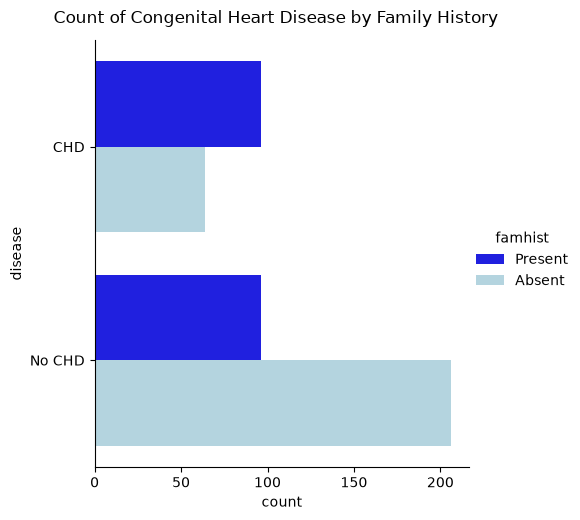

In [54]:
df["disease"] = np.where(df["chd"] == 1, "CHD", "No CHD")

# Keys in palette MUST match the categories present in 'famhist'
palette = {
    "Present": "blue",
    "Absent": "lightblue",
}

g = sns.catplot(
    data=df,
    y="disease",
    hue="famhist",  # Column that actually exists in SAheart
    kind="count",
    palette=palette
)

g.fig.suptitle("Count of Congenital Heart Disease by Family History", y=1.03)


We will train a logistic regression model, and predict on the test data. The decision rule is the following:

$$\hat{y} = \begin{cases}1 \text{ if } \frac{\exp\left(\hat{\beta}_0+\boldsymbol{x}_i'\hat{\boldsymbol{\beta}}\right)}{1+\exp\left(\hat{\beta}_0+\boldsymbol{x}_i'\hat{\boldsymbol{\beta}}\right)}\geq 1/2 \\
0 \text{ otherwise}\end{cases},$$

where $\boldsymbol{x}_i$ is the realization of the features for individual $i$ in the test dataset. 


In [55]:
# First, split the data into training and testing sets
df['famhist'] = (df['famhist'] == 'Present').astype(int)
X = df[cols]
y = df['chd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test) # by default, if p>= 0.5 we predict 1, else 0. 

print(classification_report(y_test, predictions))
print('Predicted labels: ', predictions)
print('F1-score: ', f1_score(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           0       0.78      0.87      0.82        61
           1       0.68      0.53      0.60        32

    accuracy                           0.75        93
   macro avg       0.73      0.70      0.71        93
weighted avg       0.75      0.75      0.74        93

Predicted labels:  [1 0 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0]
F1-score:  0.5964912280701754


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[53,  8],
       [15, 17]])

### Logistic Regression Performance on the Test Set

The following classification report summarizes the performance of the logistic regression model on the unseen test dataset. It provides several evaluation metrics that assess how well the classifier distinguishes between the two classes. Since the dataset is a binary classification problem, the report presents the performance separately for each class, followed by overall summary statistics.

| Class | Precision | Recall | F1-score | Support |
|-------|----------:|-------:|---------:|--------:|
| 0 | 0.74 | 0.80 | 0.77 | 61 |
| 1 | 0.56 | 0.47 | 0.51 | 32 |

Overall metrics:

- **Accuracy:** 0.69
- **Macro Average:** Precision = 0.65, Recall = 0.64, F1-score = 0.64
- **Weighted Average:** Precision = 0.68, Recall = 0.69, F1-score = 0.68

#### Precision

Precision measures the proportion of positive predictions that are actually correct. It answers the question:

> *When the model predicts a particular class, how often is it correct?*

Mathematically,

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

where:

- $TP$ = True Positives
- $FP$ = False Positives

For **Class 0**, the precision is **0.74**, meaning that 74% of all instances predicted as Class 0 were correctly classified.

For **Class 1**, the precision is **0.56**, indicating that only 56% of the instances predicted as Class 1 were actually Class 1. This suggests that the model produces a relatively larger number of false positive predictions for Class 1.

---

#### Recall

Recall measures the proportion of actual instances of a class that are correctly identified by the model. It answers the question:

> *Of all the true instances belonging to a class, how many were detected?*

It is defined as

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

where:

- $FN$ = False Negatives

For **Class 0**, the recall is **0.80**, meaning that the model correctly identifies 80% of all actual Class 0 samples.

For **Class 1**, the recall is **0.47**, meaning that only 47% of the true Class 1 instances were detected. More than half of the actual Class 1 samples were therefore misclassified as Class 0, indicating that the model has difficulty identifying this class.

---

#### F1-score

The F1-score combines precision and recall into a single metric by calculating their harmonic mean. Unlike the arithmetic mean, the harmonic mean penalizes situations where one metric is significantly lower than the other.

The F1-score is calculated as

$$
F_1 = 2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

A higher F1-score indicates a better balance between precision and recall.

For **Class 0**, the F1-score is **0.77**, indicating strong and balanced predictive performance.

For **Class 1**, the F1-score is **0.51**, which is substantially lower. This reflects the comparatively weak ability of the model to correctly classify Class 1 observations while maintaining reasonable precision.

---

#### Support

Support represents the number of actual observations belonging to each class in the test dataset. Unlike the previous metrics, it is not a performance measure but rather provides information about the class distribution.

In this test set:

- **Class 0** contains **61** observations.
- **Class 1** contains **32** observations.

The larger number of Class 0 samples indicates that the test dataset is moderately imbalanced. Such imbalance can influence the classifier to favor the majority class, often resulting in better performance for Class 0 than for Class 1.

---

#### Accuracy

Accuracy measures the overall proportion of correctly classified instances across all classes.

It is defined as

$$
\text{Accuracy} =
\frac{TP + TN}
{TP + TN + FP + FN}
$$

where:

- $TN$ = True Negatives

The model achieves an **accuracy of 0.69**, meaning that approximately **69%** of the test samples were classified correctly.

Although accuracy provides a useful overall measure of performance, it should not be interpreted in isolation, particularly when the class distribution is imbalanced. In such cases, metrics such as precision, recall, and the F1-score provide a more comprehensive assessment of the classifier's effectiveness.

---

#### Macro Average

The macro average computes each evaluation metric independently for every class and then calculates their unweighted arithmetic mean.

For example,

$$
\text{Macro Precision}
=
\frac{\text{Precision}_0 + \text{Precision}_1}{2}
$$

The same approach is applied to recall and F1-score.

Since each class contributes equally regardless of its size, the macro average is particularly useful for evaluating whether the classifier performs consistently across all classes.

The macro-average F1-score of **0.64** indicates that, when both classes are considered equally important, the overall classification performance is moderate.

---

#### Weighted Average

The weighted average also computes the metrics for each class individually, but each class is weighted according to its support.

For example,

$$
\text{Weighted F1}
=
\frac{
F_{1,0}\times \text{Support}_0 +
F_{1,1}\times \text{Support}_1
}{
\text{Support}_0+\text{Support}_1
}
$$

This approach gives greater influence to classes with more observations.

The weighted-average F1-score of **0.68** is higher than the macro-average F1-score because the model performs considerably better on Class 0, which also represents the majority of the test samples.

---

#### Overall Interpretation

The logistic regression model demonstrates **moderate predictive performance** on the test dataset, achieving an overall accuracy of **69%**. The model performs substantially better on **Class 0** than on **Class 1**, as evidenced by the higher precision, recall, and F1-score for Class 0.

The relatively low recall (**0.47**) and F1-score (**0.51**) for Class 1 indicate that the classifier struggles to correctly identify many instances of the minority class. This difference in performance is likely influenced by the unequal class distribution in the test data, where Class 0 contains nearly twice as many observations as Class 1.

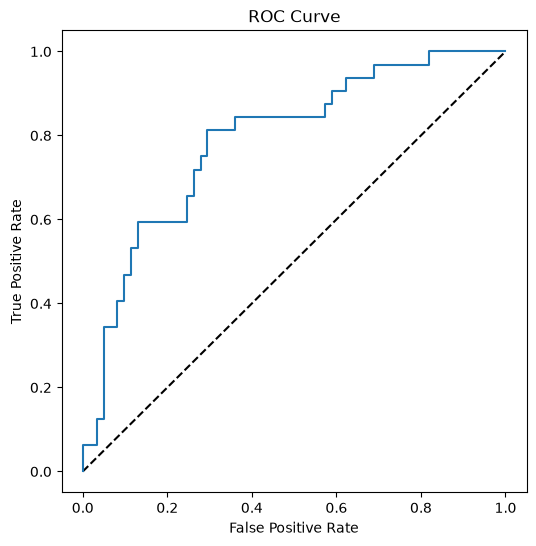

0.7873975409836065


In [56]:
y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc = roc_auc_score(y_test,y_scores[:,1])
print(auc)

### Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve provides a graphical evaluation of the binary logistic regression classifier by illustrating its performance across all possible classification thresholds. Unlike accuracy or the classification report, which evaluate the model at a single decision threshold (typically 0.5), the ROC curve measures the model's ability to discriminate between the two classes independently of any specific threshold.

The ROC curve is constructed by plotting the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** as the classification threshold is varied.

---

#### True Positive Rate (Sensitivity)

The True Positive Rate measures the proportion of actual positive observations that are correctly identified by the classifier. It is also referred to as **Sensitivity** or **Recall**.

It is defined as

$$
\text{TPR} =
\frac{TP}{TP + FN}
$$

where

- \(TP\) denotes the number of True Positives,
- \(FN\) denotes the number of False Negatives.

A higher TPR indicates that the model correctly identifies a larger proportion of positive samples.

---

#### False Positive Rate

The False Positive Rate measures the proportion of actual negative observations that are incorrectly classified as positive.

It is calculated as

$$
\text{FPR} =
\frac{FP}{FP + TN}
$$

where

- \(FP\) denotes the number of False Positives,
- \(TN\) denotes the number of True Negatives.

A lower FPR is desirable because it indicates fewer incorrect positive predictions.

---

#### Interpretation of the ROC Curve

The ROC curve illustrates the trade-off between sensitivity (TPR) and specificity as the classification threshold changes.

The **dashed diagonal line** represents the performance of a random classifier. Along this line,

$$
\text{TPR} = \text{FPR},
$$

meaning that the classifier performs no better than random guessing.

An effective classifier produces a ROC curve that lies well above this diagonal and approaches the upper-left corner of the graph. The upper-left corner corresponds to the ideal classifier with

$$
\text{TPR} = 1
\quad\text{and}\quad
\text{FPR} = 0,
$$

indicating that all positive instances are correctly detected while no negative instances are incorrectly classified.

In the present model, the ROC curve remains consistently above the diagonal reference line throughout most of the threshold range. This indicates that the logistic regression model possesses meaningful discriminative ability and performs substantially better than random classification.

The steep initial increase in the curve demonstrates that the classifier is able to achieve a noticeable improvement in the true positive rate while introducing only a relatively small increase in false positive predictions. As the threshold decreases further, the curve gradually approaches the upper-right corner, reflecting the expected trade-off between correctly identifying additional positive instances and increasing the number of false positives.

---

#### Area Under the Curve (AUC)

A common quantitative summary of the ROC curve is the **Area Under the Curve (AUC)**. The AUC measures the probability that the classifier assigns a higher predicted probability to a randomly selected positive instance than to a randomly selected negative instance.

$$
0 \leq \text{AUC} \leq 1,
$$

where

- $(\text{AUC}=1)$ represents perfect classification,
- $(\text{AUC}=0.5)$ corresponds to random guessing,
- values between 0.7 and 0.8 generally indicate acceptable discrimination,
- values between 0.8 and 0.9 indicate good discrimination,
- values greater than 0.9 indicate excellent discrimination.

---

#### Overall Interpretation

The ROC curve demonstrates that the logistic regression classifier is capable of distinguishing between the two classes with reasonable effectiveness across a range of decision thresholds. The curve consistently lies above the random-classification baseline, indicating that the model extracts useful predictive information from the input features.